# Sampler クイックスタート — Binary Lens Static

`lcbinint` の ensemble sampler（emcee 方式）を使い、  
人工データから binary lens パラメータを posterior sampling する最小限の例。

## 流れ

1. 真のパラメータで合成光度曲線を生成（ガウスノイズ付き）
2. `bayes.Model` にデータとプライアーを登録
3. `run_sampler` で MCMC を実行
4. チェーン・コーナープロットで結果を確認

In [1]:
import sys
from pathlib import Path

# ローカルビルドを優先（build → build_new の順で探す）
for build_dir in ("build", "build_new"):
    p = next(
        (r / build_dir for r in (Path.cwd(), *Path.cwd().parents) if (r / build_dir).is_dir()),
        None,
    )
    if p is not None:
        sys.path.insert(0, str(p))
        break

import numpy as np
import matplotlib.pyplot as plt
import lcbinint as lci

## 1. 合成データの生成

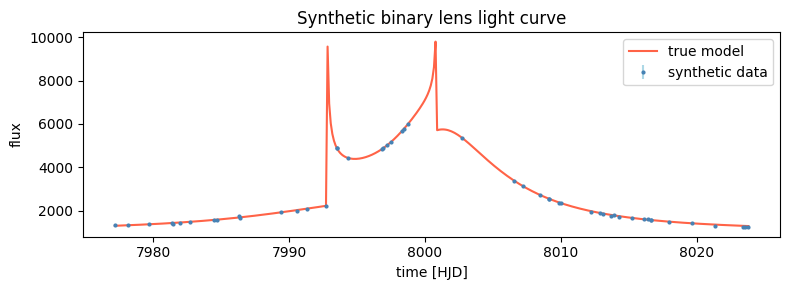

True parameters: {'t0': 8000.0, 'tE': 20.0, 'u0': 0.15, 's': 1.1, 'q': 0.05, 'alpha': 0.5}


In [2]:
rng = np.random.default_rng(42)

# 真のモデルパラメータ
TRUE = dict(t0=8000.0, tE=20.0, u0=0.15, s=1.1, q=0.05, alpha=0.5)

# 測定時刻（50 点）
times = np.sort(rng.uniform(TRUE["t0"] - 25, TRUE["t0"] + 25, 50))

# 真の増光率を計算
lc_ref = lci.lc.LightCurve()
mag_true = lc_ref(times, **TRUE)

# flux = Fs * A + Fb にノイズを乗せる
Fs_true, Fb_true = 1000.0, 50.0
sigma = 30.0
flux_true = Fs_true * mag_true + Fb_true
flux_obs  = flux_true + rng.normal(0, sigma, len(times))
flux_err  = np.full(len(times), sigma)

fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(times, flux_obs, flux_err, fmt=".", ms=4, color="steelblue", ecolor="lightblue",
            label="synthetic data", zorder=3)
ax.plot(np.linspace(times[0], times[-1], 400),
        Fs_true * lc_ref(np.linspace(times[0], times[-1], 400), **TRUE) + Fb_true,
        color="tomato", lw=1.5, label="true model")
ax.set(xlabel="time [HJD]", ylabel="flux", title="Synthetic binary lens light curve")
ax.legend()
plt.tight_layout()
plt.show()

print("True parameters:", TRUE)

## 2. モデルの構築

データを `obs.LightCurveData` に格納し、`bayes.Model` に渡す。  
`model.param(name, prior)` でサンプリングするパラメータとプライアーを登録。  
`model.flux()` でフラックスパラメータ（Fs, Fb）の線形解析解を有効化。

In [3]:
data = lci.obs.LightCurveData(times, flux_obs, flux_err, name="synthetic")

lc_model = lci.lc.LightCurve()
model = lci.bayes.Model(light_curve=lc_model, data=data)

# プライアー登録（真値を含む範囲に設定）
model.param("t0",    lci.bayes.Uniform(7990, 8010))
model.param("tE",    lci.bayes.Uniform(5, 60))
model.param("u0",    lci.bayes.Uniform(0.0, 1.0))
model.param("s",     lci.bayes.Uniform(0.5, 2.0))
model.param("q",     lci.bayes.LogUniform(1e-3, 0.5))  # log-space sampling
model.param("alpha", lci.bayes.Uniform(0, np.pi))

model.flux()        # Fs, Fb を線形解析解で marginalize
model.likelihood()  # Gaussian likelihood

print("Parameters to sample:", model.param_names)
print("n_params:", model.n_params())

# 真値での log_prob 確認（log(q) = log-space param）
theta_true = [TRUE["t0"], TRUE["tE"], TRUE["u0"], TRUE["s"], np.log(TRUE["q"]), TRUE["alpha"]]
print(f"log_prob at truth: {model.log_prob(theta_true):.2f}")
print(f"chi2     at truth: {model.chi2(theta_true):.2f}  (n_data={model.n_data})")

Parameters to sample: ['t0', 'tE', 'u0', 's', 'q', 'alpha']
n_params: 6
log_prob at truth: -24.67
chi2     at truth: 28.58  (n_data=50)


## 3. MCMC 実行

`run_sampler` でアンサンブルサンプラーを回す。  
このクイックスタートでは 32 walkers、burnin=200 + 本番 300 ステップ（合計 ~1-2分）。

In [4]:
opts = lci.SamplerOptions(
    nwalkers  = 32,
    log_every = 50,
    auto_stop = False,  # 短いので収束チェックをオフ
)

chain = lci.run_sampler(model, nsteps=300, burnin=200, options=opts)

print(chain)
print(f"Acceptance fraction: {chain.acceptance_fraction:.3f}")

lcbinint sampler | 32 walkers | 6 params | burnin=200 | nsteps=300


  [burnin  50/200]  accept=0.160


  [burnin 100/200]  accept=0.119


  [burnin 150/200]  accept=0.095


  [burnin 200/200]  accept=0.081


...

  [step 200/300]  accept=0.057  log_prob=-3483.00  elapsed=0.3s


  [step 250/300]  accept=0.054  log_prob=-3447.07  elapsed=0.4s


  [step 300/300]  accept=0.051  log_prob=-3440.98  elapsed=0.4s


  Done. 300 production steps | accept=0.051 | elapsed=0.4s


<sample.Chain nsteps=300 nwalkers=32 ndim=6 acceptance=0.050>
Acceptance fraction: 0.051


## 4. チェーントレースの確認

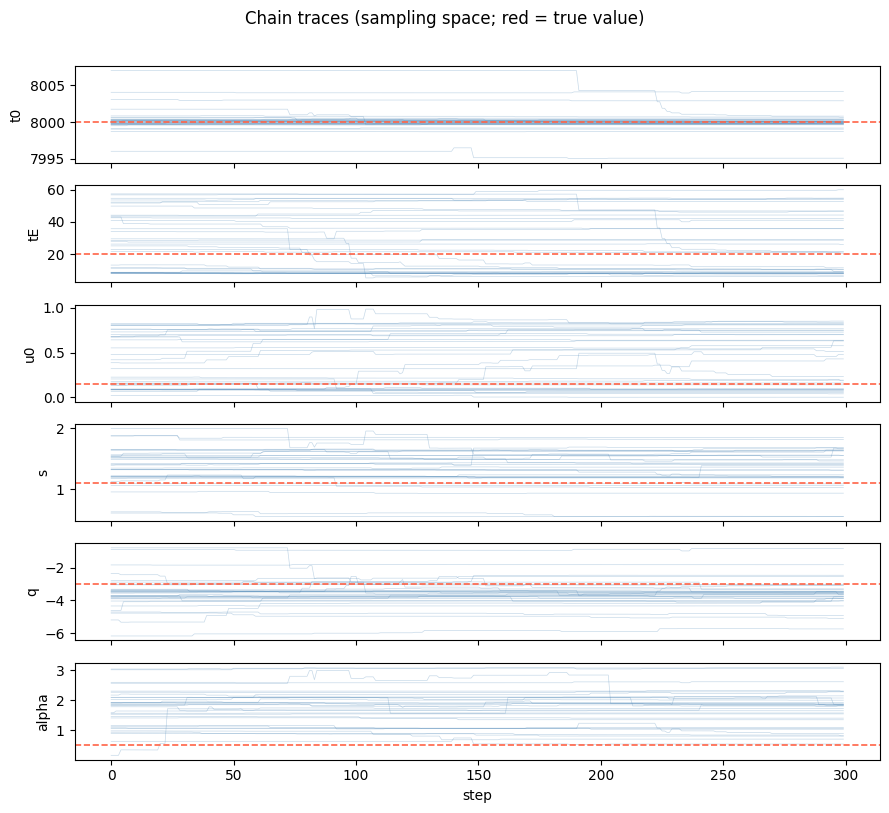

In [5]:
labels = model.param_names  # ['t0', 'tE', 'u0', 's', 'q', 'alpha']
# chain.samples は log-transform を元に戻した physical space の値
samples_phys = chain.samples  # shape (nsteps*nwalkers, ndim)
chain_3d = chain.get_chain()  # shape (nsteps, nwalkers, ndim)  — sampling space (q は log)
transforms = chain.transforms  # ["", "", "", "", "log", ""]

fig, axes = plt.subplots(len(labels), 1, figsize=(9, 8), sharex=True)
true_vals = [TRUE["t0"], TRUE["tE"], TRUE["u0"], TRUE["s"], TRUE["q"], TRUE["alpha"]]
for i, (ax, lbl, tv) in enumerate(zip(axes, labels, true_vals)):
    ax.plot(chain_3d[:, :, i], alpha=0.3, lw=0.5, color="steelblue")
    ax.set_ylabel(lbl)
    # chain は sampling space なので log-transform パラメータは log(tv) で比較
    tv_sampling = np.log(tv) if (transforms and transforms[i] == "log") else tv
    ax.axhline(tv_sampling, color="tomato", lw=1.2, ls="--")

axes[-1].set_xlabel("step")
fig.suptitle("Chain traces (sampling space; red = true value)", y=1.01)
plt.tight_layout()
plt.show()

## 5. 事後分布の確認（1D マージナル）

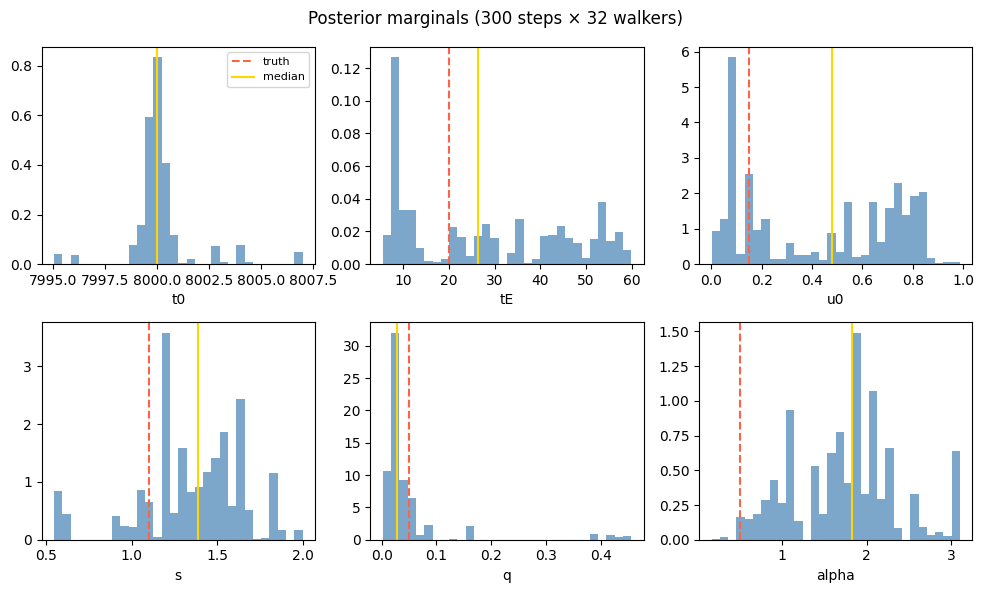


Parameter summary (physical space):
param        truth    median      16th      84th
t0        8000.0000  8000.0145  7999.6307  8000.5174
tE         20.0000   26.3889    8.5011   52.5654
u0          0.1500    0.4784    0.0833    0.7681
s           1.1000    1.3881    1.0933    1.6340
q           0.0500    0.0288    0.0169    0.0541
alpha       0.5000    1.8317    1.0555    2.2699


In [6]:
ndim = samples_phys.shape[1]
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for i, (ax, lbl, tv) in enumerate(zip(axes, labels, true_vals)):
    col = samples_phys[:, i]
    ax.hist(col, bins=30, color="steelblue", alpha=0.7, density=True)
    ax.axvline(tv,          color="tomato",  lw=1.5, ls="--", label="truth")
    ax.axvline(np.median(col), color="gold", lw=1.5, ls="-",  label="median")
    ax.set_xlabel(lbl)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("Posterior marginals (300 steps × 32 walkers)")
plt.tight_layout()
plt.show()

# サマリー表示
print("\nParameter summary (physical space):")
print(f"{'param':8s}  {'truth':>8s}  {'median':>8s}  {'16th':>8s}  {'84th':>8s}")
for lbl, tv in zip(labels, true_vals):
    s = chain.summary()[lbl]
    print(f"{lbl:8s}  {tv:8.4f}  {s['median']:8.4f}  {s['lo']:8.4f}  {s['hi']:8.4f}")

## 6. 最良モデルの重ね描き

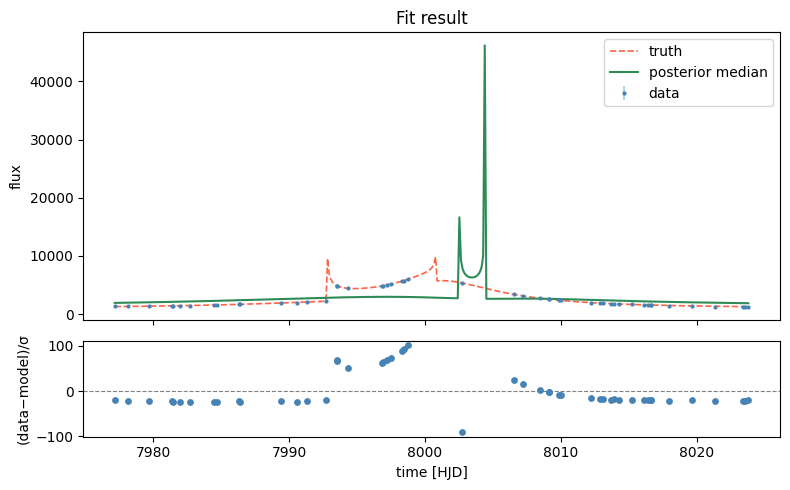

In [7]:
# median パラメータで光度曲線を描く
summary = chain.summary()
transforms = chain.transforms

# sampling space での median（model.fluxes() は sampling space を期待する）
raw_flat = chain.flat_samples  # (nsteps*nwalkers, ndim)  — sampling space
theta_med_raw = np.median(raw_flat, axis=0).tolist()

# physical space での median（lc_model の呼び出しに使う）
p_med_phys = {}
for i, lbl in enumerate(labels):
    p_med_phys[lbl] = summary[lbl]['median']  # summary() は physical space

t_dense = np.linspace(times[0], times[-1], 400)
mag_med = lc_model(t_dense, **p_med_phys)

fluxes_med = model.fluxes(theta_med_raw)
Fs_med = fluxes_med["synthetic"]["Fs"]
Fb_med = fluxes_med["synthetic"]["Fb"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})
ax1.errorbar(times, flux_obs, flux_err, fmt=".", ms=4, color="steelblue",
             ecolor="lightblue", zorder=3, label="data")
ax1.plot(t_dense, Fs_true * lc_ref(t_dense, **TRUE) + Fb_true,
         color="tomato", lw=1.2, ls="--", label="truth")
ax1.plot(t_dense, Fs_med * mag_med + Fb_med,
         color="seagreen", lw=1.5, label="posterior median")
ax1.set_ylabel("flux")
ax1.set_title("Fit result")
ax1.legend()

flux_model_at_data = Fs_med * lc_model(times, **p_med_phys) + Fb_med
residuals = (flux_obs - flux_model_at_data) / flux_err
ax2.scatter(times, residuals, s=15, color="steelblue", zorder=3)
ax2.axhline(0, color="gray", lw=0.8, ls="--")
ax2.set(xlabel="time [HJD]", ylabel="(data−model)/σ")
plt.tight_layout()
plt.show()